# Logistic Regression from Scratch

## Objective
Implement binary Logistic Regression from scratch using NumPy.

To be implemented:
1. Sigmoid
2. Linear score
3. Predicted probabilities
4. Cost function
5. Gradients
6. One gradient-descent update
7. Complete gradient descent
8. Class prediction
9. Accuracy
10. Decision boundary

**Rules:** Use NumPy. Do not use `sklearn.linear_model.LogisticRegression`. Complete only cells marked **YOUR CODE HERE**.

## 1. Import Libraries

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# np.random.seed(42)

## 2. Load the Dataset

`X` contains two features and `y` contains binary class labels.

Inspect the shapes before continuing.

In [41]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 2)
y shape: (12,)


## 3. Visualize the Dataset

Plot Class 0 and Class 1 using different markers or colours.

- Feature 1 → x-axis
- Feature 2 → y-axis

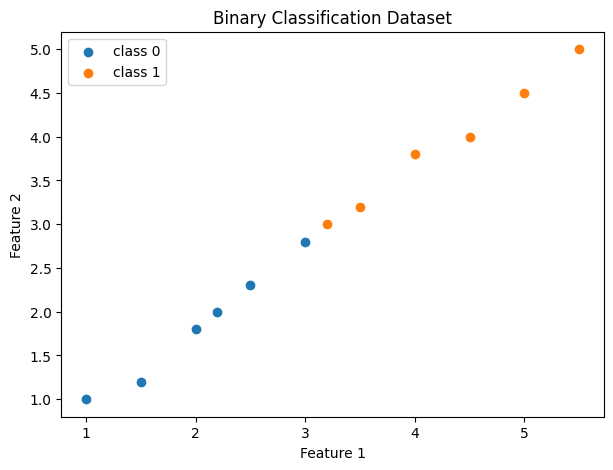

In [71]:
plt.figure(figsize=(7,5))

# YOUR CODE HERE
for _class in np.unique(y):
    plt.scatter(X[y==_class,0],X[y==_class,1],label=f"class {_class}")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()

plt.show()

## 4. Logistic Regression Model

The model first calculates

$$
z = Xw+b
$$

and then

$$
\hat y = \sigma(z)
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

If `X.shape = (m,n)` and `w.shape = (n,)`, then `X @ w` has shape `(m,)`.

## 5. Step 1 — Implement Sigmoid

### Task
Complete `sigmoid(z)`.

Use `np.exp()`. Your function should work for both a scalar and a NumPy array.

In [45]:
def sigmoid(z):
    # YOUR CODE HERE
    x= 1/(1+ np.exp(-z))
    return x

In [46]:
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))

# Remember: sigmoid(0) should be 0.5

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


## 6. Step 2 — Compute the Linear Score

Implement

`z = X @ w + b`

### Hint
Use the `@` operator for matrix-vector multiplication.

In [47]:
def compute_z(X, w, b):
    # YOUR CODE HERE
    z= X @ w + b
    return z

In [48]:
w = np.zeros(X.shape[1])
b = 0.0

z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

z: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
z shape: (12,)


## 7. Step 3 — Compute Predicted Probabilities

The predicted probability is

$$
\hat y = \sigma(Xw+b)
$$

### Task
Implement `predict_probability()` using the functions you have already written.

In [49]:
def predict_probability(X, w, b):
    # YOUR CODE HERE
    epsilon = 1e-15
    z=compute_z(X,w,b)
    y_hat = np.clip(sigmoid(z),epsilon,1-epsilon)
    return y_hat

In [50]:
probabilities = predict_probability(X, w, b)
print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


## 8. Step 4 — Implement the Cost Function

For binary Logistic Regression,

$$
J =
-\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log(\hat y^{(i)})
+
(1-y^{(i)})\log(1-\hat y^{(i)})
\right]
$$

Use `np.clip()` to avoid taking `log(0)`.

### Hint
```python
epsilon = 1e-15
probabilities = np.clip(probabilities, epsilon, 1-epsilon)
```

In [51]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    # YOUR CODE HERE
    y_hat = predict_probability(X,w,b)

    cost = -1/m * np.sum(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

    return cost

In [52]:
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)

# With w=0 and b=0, every probability is 0.5.

Initial cost: 0.6931471805599452


## 9. Step 5 — Compute the Gradients

The gradients are

$$
dw = \frac{1}{m}X^T(\hat y-y)
$$

$$
db = \frac{1}{m}\sum(\hat y-y)
$$

### Shape check

If

```text
X.shape = (m,n)
w.shape = (n,)
y.shape = (m,)
```

then

```text
X.T.shape = (n,m)
y_hat-y   = (m,)
dw        = (n,)
```

Do not use a loop over training examples. Rather, use broadcasting.

In [53]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]

    # YOUR CODE HERE
    y_hat = predict_probability(X,w,b)

    dw=1/m*np.dot(X.T,(y_hat-y))
    db=1/m*np.sum((y_hat-y))

    return dw, db

In [54]:
dw, db = compute_gradients(X, y, w, b)

print("dw:", dw)
print("dw shape:", dw.shape)
print("db:", db)

dw: [-0.5625     -0.51666667]
dw shape: (2,)
db: 0.0


## 10. Step 6 — Implement One Gradient-Descent Update

Use

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

### Task
Compute the gradients, update `w` and `b`, and return them.

In [55]:
def gradient_descent_step(X, y, w, b, learning_rate):
    # YOUR CODE HERE
    dw, db = compute_gradients(X, y, w, b)
    
    w -= learning_rate*dw
    b -= learning_rate*db

    return w, b

## 11. Step 7 — Implement Complete Gradient Descent

For each iteration:
1. Compute probabilities.
2. Compute cost.
3. Compute gradients.
4. Update parameters.
5. Store the cost.

In [56]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):

    w = np.zeros(X.shape[1])
    b = 0.0

    cost_history = []

    for i in range(num_iterations):

        # YOUR CODE HERE
        probabilities= predict_probability(X,w,b)
        cost = compute_cost(X,y,w,b)
        dw,db = compute_gradients(X,y,w,b)

        w,b = gradient_descent_step(X,y,w,b,learning_rate)
        
        cost_history.append(cost)

    return w, b, cost_history

## 12. Train the Model

Use learning rate `0.1` and `1000` iterations.

In [57]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(
    X, y, learning_rate, num_iterations
)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

Final weights: [0.93237099 1.04970645]
Final bias: -5.656246822064308
Final cost: 0.20888817201258195


## 13. Plot the Cost

Plot iteration number against cost.

### Expected observation
The cost should generally decrease during training.

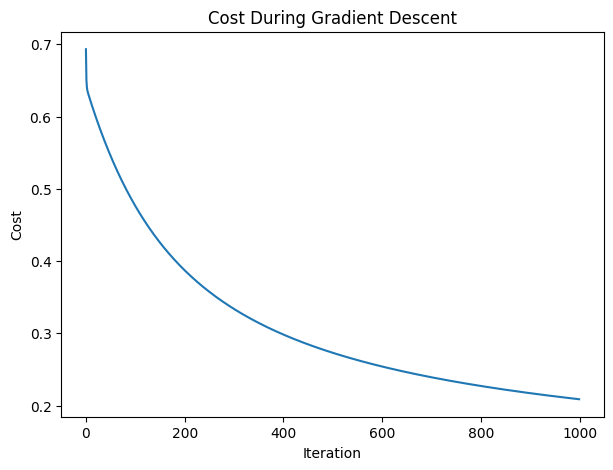

In [58]:
plt.figure(figsize=(7,5))

# YOUR CODE HERE
plt.plot(cost_history)


plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.show()

In [59]:
len(cost_history)

1000

## 14. Step 8 — Convert Probabilities into Class Predictions

Use the rule

$$
\hat y =
\begin{cases}
1 & \text{if probability} \geq 0.5\\
0 & \text{otherwise}
\end{cases}
$$

### Hint
```python
(probabilities >= threshold).astype(int)
```

In [60]:
def predict(X, w, b, threshold=0.5):
    # YOUR CODE HERE
    prob=predict_probability(X,w,b)
    prob=(prob>= threshold).astype(int)
    return prob

In [61]:
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Actual:      [0 0 0 0 0 0 1 1 1 1 1 1]


## 15. Step 9 — Calculate Accuracy

$$
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

### Task
Implement `accuracy()` using NumPy.

In [90]:
def accuracy(y_true, y_pred):
    # YOUR CODE HERE
    acc= np.sum(y_pred==y_true)/len(y_true)
    return acc

In [91]:
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 0.9166666666666666


## 16. Step 10 — Visualize the Decision Boundary

For two features, the decision boundary is

$$
w_1x_1+w_2x_2+b=0
$$

Therefore,

$$
x_2=-\frac{w_1x_1+b}{w_2}
$$

### Task
Plot the two classes and the learned decision boundary.

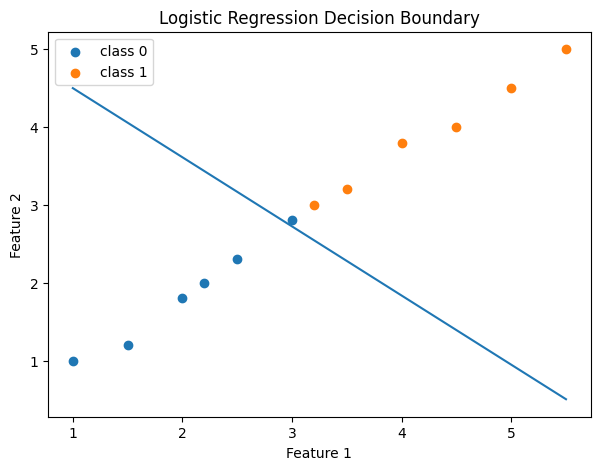

In [76]:
plt.figure(figsize=(7,5))

# YOUR CODE HERE
x1= np.linspace(min(X[:,0]),max(X[:,0]),100)
x2 = -(w[0]*x1 + b)/w[1]

for _class in np.unique(y):
    plt.scatter(X[y==_class,0],X[y==_class,1],label=f"class {_class}")

plt.plot(x1,x2)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Test your understanding — Learning Rate Experiment

Train the model using:

- `0.001`
- `0.1`
- `1.0`

Record the final cost and accuracy.

### Question
Which learning rate appears most appropriate for this dataset, and why?

Final cost for learning rate: 0.001 ==> [np.float64(0.6931471805599452), np.float64(0.6925654038217217), np.float64(0.6919898876321465), np.float64(0.6914205618927671), np.float64(0.6908573572321111), np.float64(0.6903002050004678), np.float64(0.6897490372646327), np.float64(0.6892037868026155), np.float64(0.6886643870983147), np.float64(0.6881307723361618), np.float64(0.6876028773957394), np.float64(0.6870806378463723), np.float64(0.6865639899416972), np.float64(0.6860528706142139), np.float64(0.6855472174698178), np.float64(0.6850469687823152), np.float64(0.6845520634879324), np.float64(0.6840624411798062), np.float64(0.6835780421024729), np.float64(0.6830988071463455), np.float64(0.6826246778421918), np.float64(0.6821555963556049), np.float64(0.6816915054814783), np.float64(0.6812323486384779), np.float64(0.6807780698635204), np.float64(0.6803286138062548), np.float64(0.6798839257235502), np.float64(0.6794439514739931), np.float64(0.6790086375123927), np.float64(0.678577930884297), 

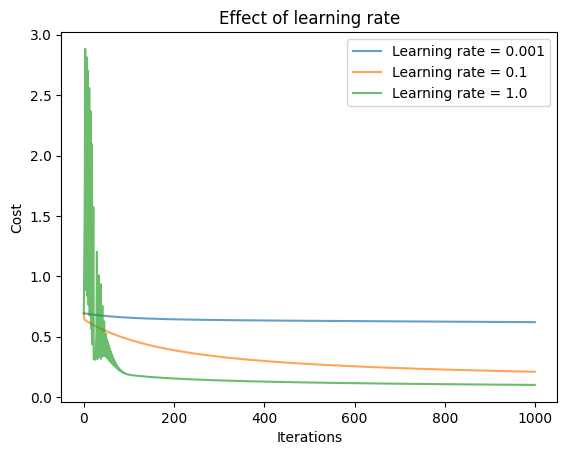

In [85]:
learning_rates = [0.001, 0.1, 1.0]

# YOUR CODE HERE

for lr in learning_rates:
    w_lr,b_lr,cost_lr=train_logistic_regression(X,y,lr,num_iterations=1000)
    print(f"Final cost for learning rate: {lr} ==> {cost_lr}")

    plt.plot(cost_lr,label=f"Learning rate = {lr}",alpha=.7)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Effect of learning rate")
plt.legend()
plt.show()


# Test your understanding — Classification Threshold

Use thresholds:

- `0.3`
- `0.5`
- `0.7`

Compare the predictions and accuracy.

### Question
Why can changing the threshold change the classification result without changing the learned weights?

In [113]:
thresholds = [0.3, 0.5, 0.7]

# YOUR CODE HERE
for th in thresholds:
    prob = predict(X,w,b,th)
    print(f"Actual:     {str(y):<15}")
    print(f"Predicted:  {str(prob):<15}")
    print(f"Accuracy:   {str(accuracy(y,prob))}")
    print()

Actual:     [0 0 0 0 0 0 1 1 1 1 1 1]
Predicted:  [0 0 0 0 0 1 1 1 1 1 1 1]
Accuracy:   0.9166666666666666

Actual:     [0 0 0 0 0 0 1 1 1 1 1 1]
Predicted:  [0 0 0 0 0 1 1 1 1 1 1 1]
Accuracy:   0.9166666666666666

Actual:     [0 0 0 0 0 0 1 1 1 1 1 1]
Predicted:  [0 0 0 0 0 0 0 1 1 1 1 1]
Accuracy:   0.9166666666666666



**Important:** Use vectorized NumPy operations wherever possible instead of loops.